In [16]:
!pip install ta yfinance pynance

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from ta.trend import MACD
from ta.momentum import RSIIndicator

In [20]:
aapl = yf.download("AAPL", start="2020-01-01", end="2024-12-31")

tsla = yf.download("TSLA", start="2020-01-01", end="2024-12-31")

amzn = yf.download("AMZN", start="2020-01-01", end="2024-12-31")

/tmp/ipykernel_25134/3179890887.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25134/3179890887.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsla = yf.download("TSLA", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25134/3179890887.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn = yf.download("AMZN", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [21]:
df = aapl.copy()

df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [22]:
df.shape

(1257, 5)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1257 non-null   float64
 1   (High, AAPL)    1257 non-null   float64
 2   (Low, AAPL)     1257 non-null   float64
 3   (Open, AAPL)    1257 non-null   float64
 4   (Volume, AAPL)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [24]:
df.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [25]:
df.reset_index(inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

df.sort_values("Date", inplace=True)

In [26]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

df["SMA_50"] = df["Close"].rolling(window=50).mean()

In [27]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

In [31]:
df.columns

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            ('SMA_20',     ''),
            ('SMA_50',     ''),
            ('EMA_20',     '')],
           names=['Price', 'Ticker'])

In [32]:
df.columns = df.columns.get_level_values(0)

In [33]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50',
       'EMA_20'],
      dtype='object', name='Price')

In [34]:
from ta.momentum import RSIIndicator

rsi = RSIIndicator(close=df["Close"], window=14)

df["RSI"] = rsi.rsi()

In [35]:
from ta.trend import MACD

macd = MACD(close=df["Close"])

df["MACD"] = macd.macd()

df["MACD_signal"] = macd.macd_signal()

In [36]:
df["Daily_Return"] = df["Close"].pct_change()

In [37]:
df.head(30)

Price,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,Daily_Return
0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN,NaN,72.333878,NaN,NaN,NaN,NaN
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,NaN,NaN,72.266902,NaN,NaN,NaN,-0.009722
2,2020-01-06,72.201393,72.239927,70.503531,70.753999,118387200,NaN,NaN,72.260663,NaN,NaN,NaN,0.007968
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000,NaN,NaN,72.222679,NaN,NaN,NaN,-0.004703
4,2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200,NaN,NaN,72.298407,NaN,NaN,NaN,0.016086
5,2020-01-09,74.568764,74.761426,73.742712,73.993172,170108400,NaN,NaN,72.514631,NaN,NaN,NaN,0.021241
6,2020-01-10,74.737358,75.300911,74.236431,74.802387,140644800,NaN,NaN,72.726319,NaN,NaN,NaN,0.002261
7,2020-01-13,76.334076,76.360571,74.934843,75.052856,121532000,NaN,NaN,73.069915,NaN,NaN,NaN,0.021364
8,2020-01-14,75.303337,76.481009,75.180518,76.271486,161954400,NaN,NaN,73.282622,NaN,NaN,NaN,-0.013503
9,2020-01-15,74.980621,75.982483,74.549530,75.103448,121923600,NaN,NaN,73.444336,NaN,NaN,NaN,-0.004286


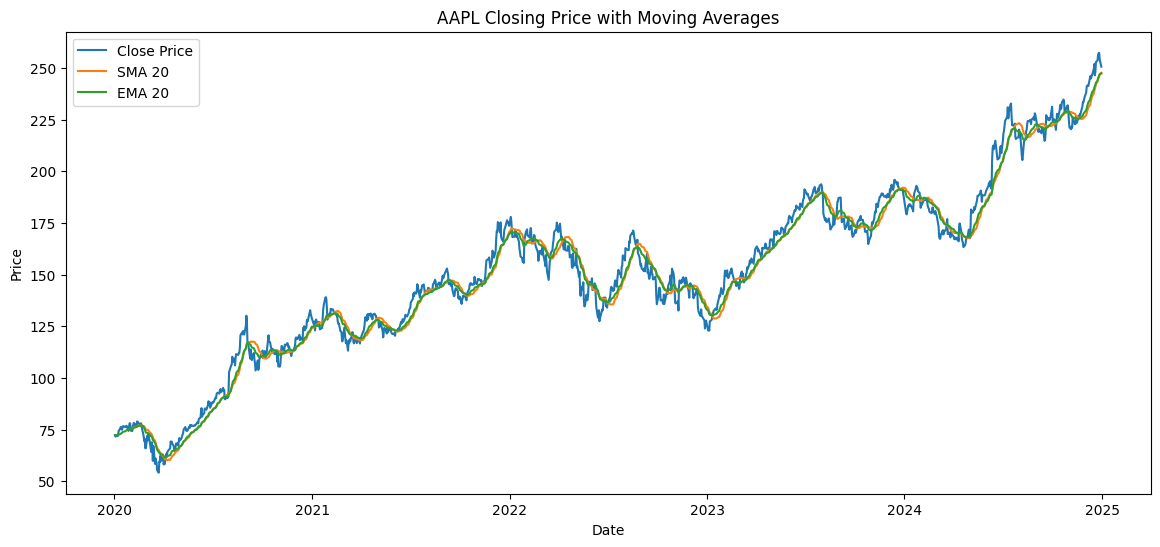

In [39]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")

plt.plot(df["Date"], df["SMA_20"], label="SMA 20")

plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("AAPL Closing Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

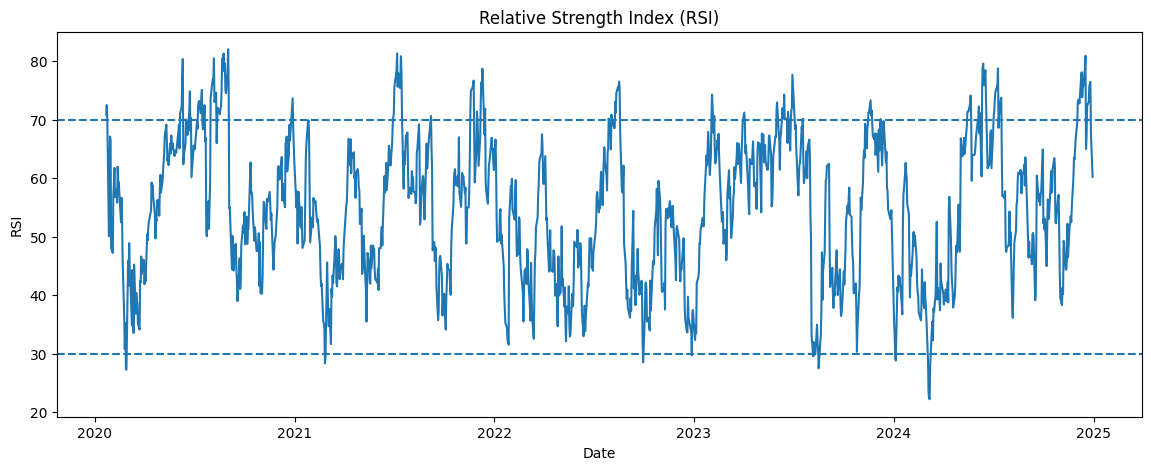

In [40]:
plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, linestyle="--")

plt.axhline(30, linestyle="--")

plt.title("Relative Strength Index (RSI)")

plt.xlabel("Date")

plt.ylabel("RSI")

plt.show()

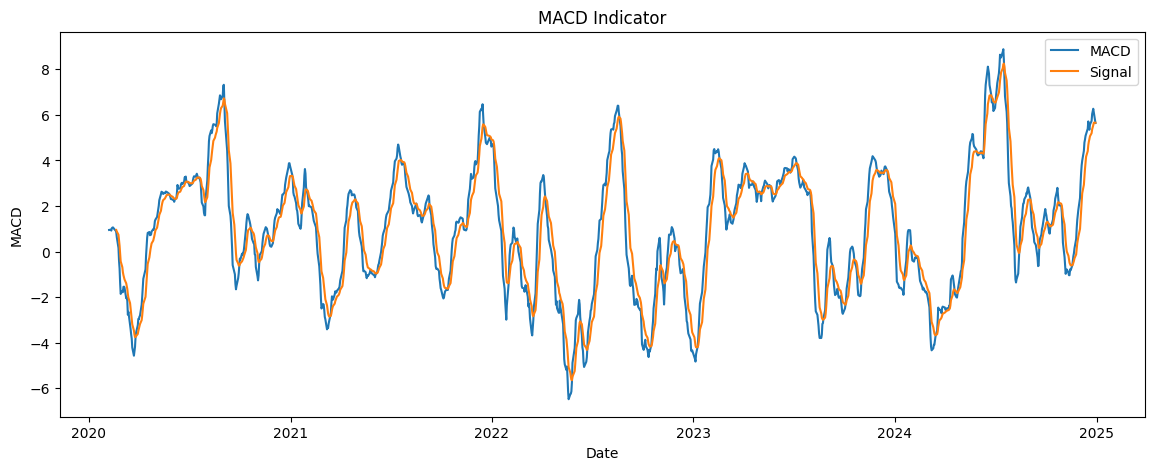

In [41]:
plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["MACD"], label="MACD")

plt.plot(df["Date"], df["MACD_signal"], label="Signal")

plt.title("MACD Indicator")

plt.xlabel("Date")

plt.ylabel("MACD")

plt.legend()

plt.show()